In [1]:
import requests
import pandas as pd

SYMBOL = 'BTCUSDT'
INTERVAL = '1m'   # Intervalle d'une minute
LIMIT = 600        # Nombre de lignes à récupérer

def data_collection_api():
    response = requests.get(
        url='https://api.binance.com/api/v3/klines',
        params={
            "symbol": SYMBOL,
            "interval": INTERVAL,
            "limit": LIMIT
        }
    )
    
    if response.status_code != 200:
        print(f"Erreur {response.status_code}")
        return None
    
    data = response.json()
    
    columns = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
    ]
    
    # Créer un DataFrame pandas
    df = pd.DataFrame(data, columns=columns)
    
    numeric_cols = ["open", "high", "low", "close", "volume",
                    "quote_asset_volume", "taker_buy_base_volume", "taker_buy_quote_volume"]
    df[numeric_cols] = df[numeric_cols].astype(float)
    
    # Convertir timestamps en microsecondes pour Spark
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms").astype('datetime64[us]')
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms").astype('datetime64[us]')
    
    return df

df = data_collection_api()

# Sauvegarder en Parquet avec fastparquet
df.to_parquet("btc_data_bronze.parquet", engine="fastparquet", index=False)

print("Fichier Parquet sauvegardé ✅")


Fichier Parquet sauvegardé ✅


In [2]:
import os
# os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/amazon-corretto-11.jdk/Contents/Home"

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Bitcoin_Data") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "false") \
    .config("spark.sql.execution.arrow.pyspark.fallback.enabled", "false") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()





your 131072x1 screen size is bogus. expect trouble
26/01/21 16:23:32 WARN Utils: Your hostname, DESKTOP-C2HJNDO resolves to a loopback address: 127.0.1.1; using 172.17.128.32 instead (on interface eth0)
26/01/21 16:23:32 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/21 16:23:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
df = spark.read.parquet("btc_data_bronze.parquet")
df.show(5)

+-------------------+--------+--------+--------+--------+--------+--------------------+------------------+----------------+---------------------+----------------------+------+
|          open_time|    open|    high|     low|   close|  volume|          close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|
+-------------------+--------+--------+--------+--------+--------+--------------------+------------------+----------------+---------------------+----------------------+------+
|2026-01-21 05:23:00|89579.28| 89590.0|89579.27| 89590.0| 2.06178|2026-01-21 05:23:...|    184710.0986633|             351|              1.91588|        171639.0254647|     0|
|2026-01-21 05:24:00| 89590.0|89590.01|89589.99|89590.01| 4.64044|2026-01-21 05:24:...|    415737.0197414|             259|              4.35718|        390359.7570946|     0|
|2026-01-21 05:25:00| 89590.0|89590.01| 89590.0| 89590.0| 0.58632|2026-01-21 05:25:...|     52528.4110236|             1

In [4]:
df.count()

600

In [5]:
df.printSchema()

root
 |-- open_time: timestamp_ntz (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: double (nullable = true)
 |-- close_time: timestamp_ntz (nullable = true)
 |-- quote_asset_volume: double (nullable = true)
 |-- number_of_trades: long (nullable = true)
 |-- taker_buy_base_volume: double (nullable = true)
 |-- taker_buy_quote_volume: double (nullable = true)
 |-- ignore: string (nullable = true)



In [6]:
df.describe().show()

26/01/21 16:29:02 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-----------------+-----------------+-----------------+-----------------+------------------+------------------+-----------------+---------------------+----------------------+------+
|summary|             open|             high|              low|            close|            volume|quote_asset_volume| number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|
+-------+-----------------+-----------------+-----------------+-----------------+------------------+------------------+-----------------+---------------------+----------------------+------+
|  count|              600|              600|              600|              600|               600|               600|              600|                  600|                   600|   600|
|   mean|89309.37328333338|89339.69988333341|89279.27163333337|89310.31260000003|13.169373249999998|1175675.6806961885|          3835.23|     6.67705023333333|      596416.150530411|   0.0|
| stddev|422.3777022626281|423.8490891702868|423.5

column "volume" contient une valeur max plus grande que min ce qui siginfie que nous pouvons avoir des outliers 114 BTC > 0.34 BTC (outliers)
column "quote_asset_volume" une valeur max plus grande que min ce qui siginfie que nous pouvons avoir des outliers (ouliers)
column "number_of_trades" une differenciation entre les valeurs min et max le marché de trads a des ups and downs selon le volume (correlation)
column "taker_buy_quote_volume" une forte demande d achat (outliers)
column "ignore" valeurs est 0 on pourra le supprimé dans la phase de preporcessing 


In [7]:
# Vérifier l'état de la session Spark
print(df.sparkSession)

In [8]:
from pyspark.sql.functions import col

cols_outliers = [
    "volume","quote_asset_volume", "number_of_trades", 
    "taker_buy_base_volume", "taker_buy_quote_volume"
]


def detect_outliers_iqr(df,column):
    #on calcule q1 et q3
    q1= df.approxQuantile(column,[0.25],0.01)[0]
    q3 = df.approxQuantile(column,[0.75],0.01)[0]

    iqr= q3 - q1

    lower = q1 -1.5 * iqr
    upper = q3 + 1.5 * iqr

    #om calcule les outliers
    outlier_count = df.filter(
        (col(column) < lower) | (col(column) > upper)
    ).count()

    return{
        "column": column,
        "Q1" : q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outliers_Count": outlier_count
    }

results = []

for c in cols_outliers:
    res = detect_outliers_iqr(df, c)
    results.append(res)

results



[{'column': 'volume',
  'Q1': 3.6724,
  'Q3': 15.77798,
  'IQR': 12.10558,
  'Lower_Bound': -14.485969999999998,
  'Upper_Bound': 33.93635,
  'Outliers_Count': 45},
 {'column': 'quote_asset_volume',
  'Q1': 327951.2758676,
  'Q3': 1408722.8680927,
  'IQR': 1080771.5922251,
  'Lower_Bound': -1293206.1124700499,
  'Upper_Bound': 3029880.25643035,
  'Outliers_Count': 45},
 {'column': 'number_of_trades',
  'Q1': 1463.0,
  'Q3': 4471.0,
  'IQR': 3008.0,
  'Lower_Bound': -3049.0,
  'Upper_Bound': 8983.0,
  'Outliers_Count': 71},
 {'column': 'taker_buy_base_volume',
  'Q1': 1.64548,
  'Q3': 7.737,
  'IQR': 6.09152,
  'Lower_Bound': -7.4918000000000005,
  'Upper_Bound': 16.87428,
  'Outliers_Count': 46},
 {'column': 'taker_buy_quote_volume',
  'Q1': 146998.9175078,
  'Q3': 688081.8568625,
  'IQR': 541082.9393546999,
  'Lower_Bound': -664625.4915242498,
  'Upper_Bound': 1499706.26589455,
  'Outliers_Count': 46}]

les outliers que nous avons remarqué est normaux puisqu'ils ont moins de 10% donc on va appliquer Capping ou Log transform

In [9]:
#verifier les valeurs nulls

from pyspark.sql.functions import  col, sum as Fsum


df.select([Fsum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+
|open_time|open|high|low|close|volume|close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|
+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+
|        0|   0|   0|  0|    0|     0|         0|                 0|               0|                    0|                     0|     0|
+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+



In [10]:
print("duplicates cols :", df.count() - df.dropDuplicates().count())

duplicates cols : 0


### prédire le prix de cloture du Bitcoin à T+10 minutes


In [11]:
from pyspark.sql.window import Window
from pyspark.sql import functions as F
from pyspark.sql.functions import col, avg

# Créer une fenêtre ordonnée par temps
window = Window.orderBy("open_time")

# Décaler la colonne 'close' de 10 lignes (10 minutes)
df = df.withColumn("close_t_plus_10", F.lead("close", 10).over(window))

 
#calcule de la Variations de prix (returns) 
window_lag =Window.orderBy("open_time")
df = df.withColumn(
    "return", 
    (F.col("close")-F.lag("close",1).over(window_lag)) / F.lag("close",1).over(window_lag)
    )

#calcule de Moyennes mobiles (5, 10 minutes)
window_avg= Window.orderBy("open_time")
window_5 =window_avg.rowsBetween(-4 , 0)
window_10 = window_avg.rowsBetween(-9,0)

df = df.withColumn("ma_05",avg(col("close")).over(window_5))
df = df.withColumn("ma_10",avg(col("close")).over(window_10)) 


#calculer le taker ratio
df= df.withColumn(
    "taker_ratio",
    F.col("taker_buy_base_volume")/F.col("volume")
)




In [12]:
from pyspark.sql.functions import  col, sum as Fsum


df.select([Fsum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

26/01/21 16:29:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 16:29:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 16:29:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 16:29:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+---------------+------+-----+-----+-----------+
|open_time|open|high|low|close|volume|close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|close_t_plus_10|return|ma_05|ma_10|taker_ratio|
+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+---------------+------+-----+-----+-----------+
|        0|   0|   0|  0|    0|     0|         0|                 0|               0|                    0|                     0|     0|             10|     1|    0|    0|          0|
+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+---------------+------+-----+-----+-----------+



In [13]:
df = df.dropna(subset=["close_t_plus_10","return"])

In [14]:
df.select([Fsum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

26/01/21 16:29:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 16:29:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 16:29:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 16:29:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+---------------+------+-----+-----+-----------+
|open_time|open|high|low|close|volume|close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|close_t_plus_10|return|ma_05|ma_10|taker_ratio|
+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+---------------+------+-----+-----+-----------+
|        0|   0|   0|  0|    0|     0|         0|                 0|               0|                    0|                     0|     0|              0|     0|    0|    0|          0|
+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+---------------+------+-----+-----+-----------+



In [15]:


# matrice de correlation

from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import numpy as np
import pandas as pd

cols_numeric = [
    "close", "volume", "quote_asset_volume", "number_of_trades",
    "taker_buy_base_volume", "taker_buy_quote_volume",
    "return", "ma_05", "ma_10", "taker_ratio", "close_t_plus_10"
]

assembler = VectorAssembler(
    inputCols=cols_numeric,
    outputCol="features"
)
df_vector = assembler.transform(df_clean).select("features")


corr_matrix = Correlation.corr(df_vector, "features").head()[0]


corr_array = corr_matrix.toArray()


corr_df = pd.DataFrame(corr_array, columns=cols_numeric, index=cols_numeric)





ModuleNotFoundError: No module named 'distutils'

In [ ]:
corr_df.head()

,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,return,ma_05,ma_10,taker_ratio,close_t_plus_10
close,1.000000,-0.252411,-0.248163,-0.507839,-0.163400,-0.160051,0.010339,0.995327,0.989242,-0.039752,0.960189
volume,-0.252411,1.000000,0.999973,0.629619,0.861986,0.861515,0.082255,-0.265629,-0.271192,0.066145,-0.242081
quote_asset_volume,-0.248163,0.999973,1.000000,0.628123,0.863067,0.862633,0.083490,-0.261516,-0.267154,0.066723,-0.238073
number_of_trades,-0.507839,0.629619,0.628123,1.000000,0.476272,0.475217,0.007527,-0.510160,-0.512017,0.032380,-0.491347
taker_buy_base_volume,-0.163400,0.861986,0.863067,0.476272,1.000000,0.999981,0.343179,-0.198665,-0.210203,0.345439,-0.161329


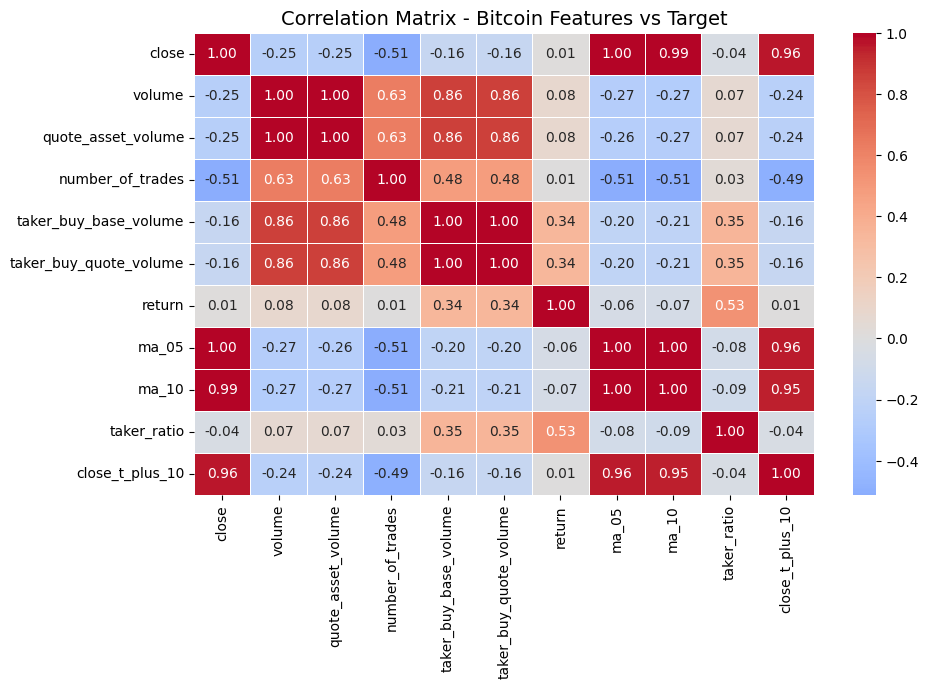

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_df,
    annot=True,       
    fmt=".2f",        
    cmap="coolwarm",   
    center=0,         
    linewidths=0.5
)

plt.title("Correlation Matrix - Bitcoin Features vs Target", fontsize=14)
plt.show()

In [ ]:
df.write.parquet("data_silver.parquet")


print("Fichier Parquet sauvegardé ✅")

26/01/21 10:07:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 10:07:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 10:07:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 10:07:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 10:07:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


Fichier Parquet sauvegardé ✅


In [ ]:
df_sl = spark.read.parquet("data_silver.parquet")
df_sl.show(5)

+-------------------+--------+--------+--------+--------+---------+--------------------+------------------+----------------+---------------------+----------------------+------+---------------+--------------------+-----------------+-----------------+-------------------+
|          open_time|    open|    high|     low|   close|   volume|          close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|close_t_plus_10|              return|            ma_05|            ma_10|        taker_ratio|
+-------------------+--------+--------+--------+--------+---------+--------------------+------------------+----------------+---------------------+----------------------+------+---------------+--------------------+-----------------+-----------------+-------------------+
|2026-01-20 23:03:00|88296.02|88296.02|88097.15|88097.16| 69.05007|2026-01-20 23:03:...|   6088295.0226226|           10479|             13.79466|       1216135.4714683|     0|       88213.0